In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import torch
import matplotlib.pyplot as plt

# Prepare ice flux (q) observation tensor

Create a tensor with columns [x_norm, y_norm, flux_x_scaled, flux_y_scaled]

In [2]:
# import region bounds
from regions import ROSS_BOUNDS

# assign region bounds
x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

## Load cleaned thickness point data

In [3]:
# Load thickness points
# NOTE: Outliers are removed from this file.
thickness = pd.read_csv("data/bedmap123_ross_onshelf_3M.csv")
thickness.describe()

,lon,lat,x,y,s,t,b,t_fa,x_norm,y_norm
count,3.239963e+06,3.239963e+06,3.239963e+06,3.239963e+06,3.239963e+06,3.239963e+06,3.239963e+06,3.239963e+06,3.239963e+06,3.239963e+06
mean,-2.248050e+01,-8.056348e+01,-6.485234e+04,-9.958565e+05,-1.309636e+02,4.335179e+02,-5.545172e+02,4.235179e+02,5.351477e-01,4.041435e-01
std,1.665693e+02,1.807049e+00,2.473085e+05,1.955685e+05,1.173392e+03,1.644394e+02,1.123187e+03,1.644394e+02,2.473085e-01,1.955685e-01
min,-1.838281e+02,-8.535144e+01,-5.854745e+05,-1.360496e+06,-9.999000e+03,0.000000e+00,-9.999000e+03,-1.000000e+01,1.452545e-02,3.950352e-02
25%,-1.677512e+02,-8.197557e+01,-2.385320e+05,-1.146891e+06,-4.872615e+00,3.312308e+02,-5.059273e+02,3.212308e+02,3.614680e-01,2.531094e-01
50%,-1.549330e+02,-8.024463e+01,-6.078004e+04,-1.010261e+06,5.045533e+00,3.834600e+02,-3.804200e+02,3.734600e+02,5.392200e-01,3.897391e-01
75%,1.695937e+02,-7.916884e+01,1.391966e+05,-8.502413e+05,1.955000e+01,5.171889e+02,-3.324044e+02,5.071889e+02,7.391966e-01,5.497587e-01
max,1.949701e+02,-7.739090e+01,3.894639e+05,-4.497456e+05,1.050800e+04,2.164640e+03,9.999000e+03,2.154640e+03,9.894639e-01,9.502544e-01


## Load raw ice velocity data

- 450 m nominal resolution
- interpolate at point locations

In [5]:
# Load ice velocity data (raw)
# TODO define local path to ice velocity data
ice_vel = xr.load_dataset("/home/kim/data/nsidc/antarctic_ice_vel_phase_map_v01.nc")
# ice_vel = xr.load_dataset("nsidc/antarctic_ice_vel_phase_map_v01.nc")

# crop
velocity = ice_vel.sel(
    x = slice(x_min, x_max), 
    y = slice(y_max, y_min))

In [6]:
# Interpolate
vel_at_points = velocity[["VX", "VY"]].interp(
    x = ("points", thickness["x"].values),
    y = ("points", thickness["y"].values),
    method = "linear",
)

# Add to dataset
thickness["VX"] = vel_at_points["VX"].values
thickness["VY"] = vel_at_points["VY"].values

print(thickness.shape)

(3239963, 14)


In [7]:
# Multiply velocity components by thickness (t_fa) to get flux components
thickness["VX_flux"] = thickness["VX"] * thickness["t_fa"]
thickness["VY_flux"] = thickness["VY"] * thickness["t_fa"]

# If you also want total flux magnitude
thickness["flux_mag"] = np.hypot(thickness["VX_flux"], thickness["VY_flux"])

# Optionally drop rows with NaNs if you want a clean dataset
# Check for NaNs
print(thickness[["VX_flux", "VY_flux", "flux_mag"]].isna().sum())

# Remove so that 3.2 M points remain
thickness = thickness.dropna(subset = ["VX_flux", "VY_flux", "flux_mag"])
print(thickness.shape)

VX_flux     31874
VY_flux     31874
flux_mag    31874
dtype: int64
(3208089, 17)


## Load MODIS MOA for visualisation backrgound

In [8]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

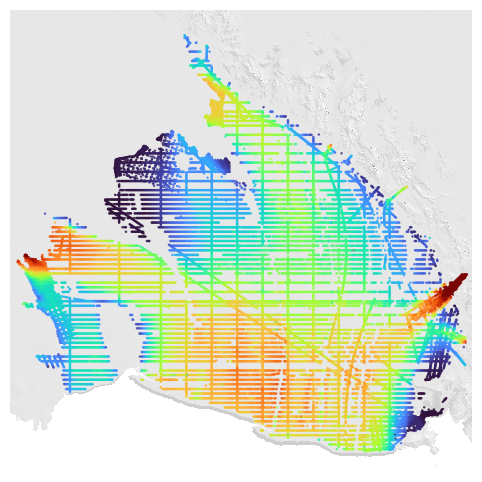

In [9]:
# Use same subsample rate as the ice thickness visualisations
SUBSAMPLE_RATE = 100

fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

# 2) SMB on top (draw second)
ax.scatter(
    thickness["x"][::SUBSAMPLE_RATE], 
    thickness["y"][::SUBSAMPLE_RATE], 
    c = thickness["flux_mag"][::SUBSAMPLE_RATE], 
    s = 0.6, 
    alpha = 0.8, 
    cmap = "turbo",
    vmin = 0,
    # 400 k worked well
    vmax = 400_000 
    )

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/ice_flux_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

## cmap

In [10]:
cmap = "turbo"
dpi = 300

# 1 x N gradient
grad = np.linspace(0, 1, 2048)[None, :]

fig = plt.figure(figsize = (6, 0.6), dpi = dpi)
ax = fig.add_axes([0, 0, 1, 1]) 
ax.imshow(grad, aspect = "auto", cmap = cmap)
ax.set_axis_off()

fig.savefig("figures/cmap/turbo_bar.png", dpi = dpi, transparent = True, bbox_inches = "tight", pad_inches = 0)
plt.close(fig)

# Visualise sparse raw flux vectors - region

(for presentation)

In [17]:
thickness

# 200 x 200 km zoomed in region
x_min_zoom = 150_250
x_max_zoom = 345_250

y_min_zoom = -1_195_250
y_max_zoom = -1_000_250

thickness_zoom = thickness[
    (thickness["x"] >= x_min_zoom) &
    (thickness["x"] <= x_max_zoom) &
    (thickness["y"] >= y_min_zoom) &
    (thickness["y"] <= y_max_zoom)
]

thickness_zoom

,lon,lat,x,y,s,t,b,b_inferred,source,t_fa,x_norm,y_norm,VX,VY,VX_flux,VY_flux,flux_mag
8,170.333300,-79.251660,196652.318700,-1.154503e+06,62.00,363.00,-905.00,False,BEDMAP1_1966-2000_AIR_BM1.csv,353.00,0.796652,0.245497,-208.799878,-667.499867,-73706.356778,-235627.453088,246886.459082
9,170.300000,-79.910000,185174.994996,-1.083318e+06,60.00,354.00,-562.00,False,BEDMAP1_1966-2000_AIR_BM1.csv,344.00,0.785175,0.316682,-248.244376,-537.734525,-85396.065318,-184980.676719,203740.861712
38,170.700000,-79.028340,193214.585630,-1.179891e+06,63.00,373.00,-870.00,False,BEDMAP1_1966-2000_AIR_BM1.csv,363.00,0.793215,0.220109,-147.316073,-688.456255,-53475.734385,-249909.620553,255566.963070
39,167.400000,-79.073330,259737.741156,-1.162000e+06,62.00,387.00,-926.00,False,BEDMAP1_1966-2000_AIR_BM1.csv,377.00,0.859738,0.238000,-195.840056,-393.640908,-73831.701158,-148402.622440,165754.210935
40,165.633300,-79.080000,295257.152344,-1.152732e+06,73.00,478.00,-1397.00,False,BEDMAP1_1966-2000_AIR_BM1.csv,468.00,0.895257,0.247268,-115.806817,-91.401148,-54197.590158,-42775.737070,69044.496238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092976,161.388714,-80.069888,345166.143953,-1.024973e+06,23.77,584.60,-560.83,False,UTIG_2010_ICECAP_AIR_BM3.csv,574.60,0.945166,0.375027,-452.342278,-481.702619,-259915.872726,-276786.324958,379693.205864
3092977,161.386977,-80.070080,345190.510621,-1.024942e+06,23.24,584.84,-561.60,False,UTIG_2010_ICECAP_AIR_BM3.csv,574.84,0.945191,0.375058,-452.399289,-481.825220,-260057.207204,-276972.409312,379925.606585
3092978,161.386080,-80.070180,345203.063474,-1.024926e+06,21.04,581.89,-560.84,False,UTIG_2010_ICECAP_AIR_BM3.csv,571.89,0.945203,0.375074,-452.429206,-481.888148,-258739.738831,-275587.012865,378013.827935
3092979,161.385210,-80.070276,345215.272674,-1.024911e+06,19.42,581.56,-562.14,False,UTIG_2010_ICECAP_AIR_BM3.csv,571.56,0.945215,0.375089,-452.457532,-481.949173,-258606.627228,-275462.869154,377832.211343


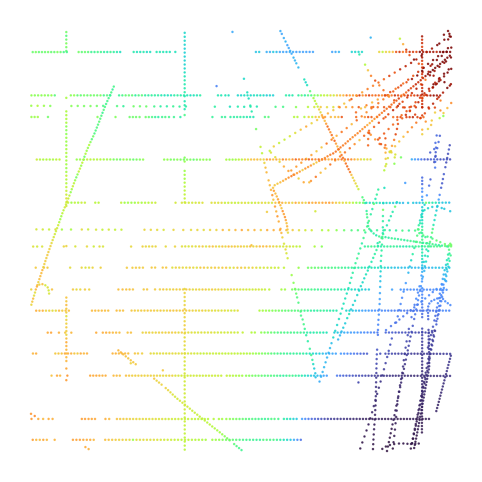

In [18]:
SUBSAMPLE_RATE = 100

fig, ax = plt.subplots(figsize = (8, 6))

# 2) SMB on top (draw second)
ax.scatter(
    thickness_zoom["x"][::SUBSAMPLE_RATE], 
    thickness_zoom["y"][::SUBSAMPLE_RATE], 
    c = thickness_zoom["flux_mag"][::SUBSAMPLE_RATE], 
    s = 0.6, 
    alpha = 0.8, 
    cmap = "turbo",
    vmin = 0,
    # 400 k worked well
    vmax = 400_000 
    )

ax.set_aspect("equal")
ax.set_axis_off()
fig.savefig("figures/ice_flux_ross_zoom.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

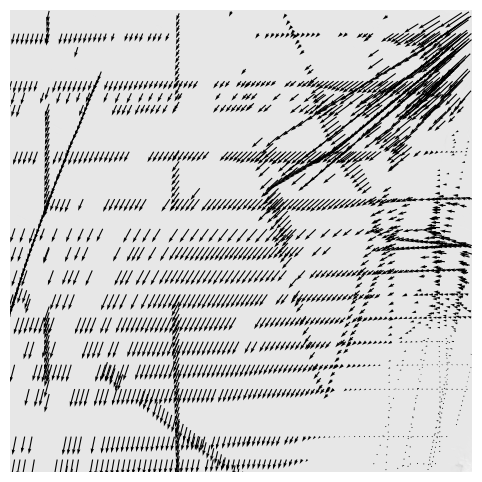

In [39]:
SUBSAMPLE_RATE = 140

fig, ax = plt.subplots(figsize = (8, 6))

ax.pcolormesh(
    modis_ross[0],
    modis_ross[1], 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4,
    zorder = 0,
)

ax.quiver(
    thickness_zoom["x"][::SUBSAMPLE_RATE], 
    thickness_zoom["y"][::SUBSAMPLE_RATE], 
    thickness_zoom["VX_flux"][::SUBSAMPLE_RATE], 
    thickness_zoom["VY_flux"][::SUBSAMPLE_RATE],
    scale = 7_000_000.0,
    # width = 0.005,
)

ax.set_ylim(y_min_zoom, y_max_zoom)
ax.set_xlim(x_min_zoom, x_max_zoom)

ax.set_aspect("equal")
ax.set_axis_off()
fig.savefig("figures/ice_flux_ross_zoom.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

## Histogram of flux magnitude

Observation: most values are under 400k.
We thus normalise by 100k.

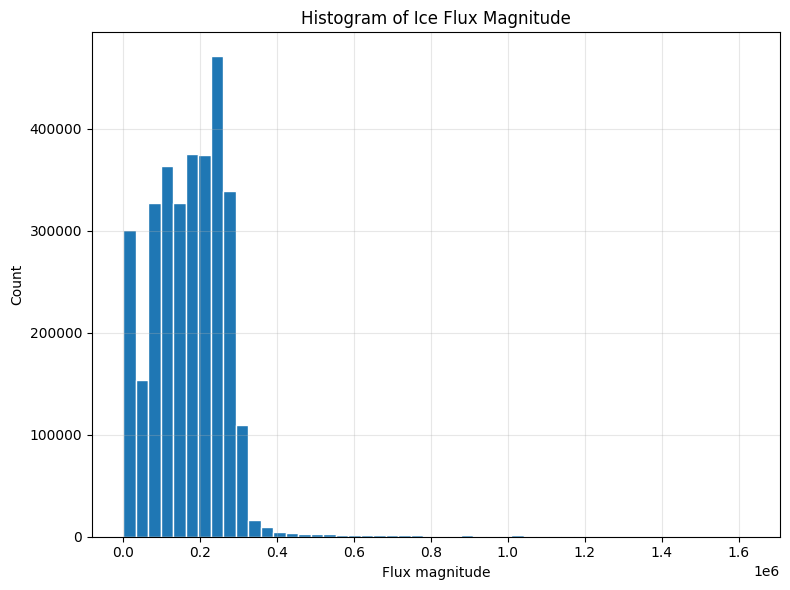

In [12]:
plt.figure(figsize = (8, 6))
plt.hist(thickness["flux_mag"], bins = 50, edgecolor="white")
plt.xlabel("Flux magnitude")
plt.ylabel("Count")
plt.title("Histogram of Ice Flux Magnitude")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

## Affirm normalisation scalar

In [13]:
# Print variance after normalisation
print(np.var(thickness["VX_flux"] / 100_000))
print(np.var(thickness["VY_flux"] / 100_000))

1.158258043399772
0.8710024484631412


## Normalise

Example: 425 meter ice * 438 meter per year (mean)  
425 * 438 = 186_150 m^2/yr

In [ ]:
# Normalize into [0, 1]
thickness["x_norm"] = (thickness["x"] - x_min) / (x_max - x_min)
thickness["y_norm"] = (thickness["y"] - y_min) / (y_max - y_min)

# Build tensor with x_norm, y_norm, scaled flux
flux_tensor = torch.tensor(
    np.stack([
        thickness["x_norm"].values,
        thickness["y_norm"].values,
        thickness["VX_flux"].values / 100_000,
        thickness["VY_flux"].values / 100_000,
    ], axis = 1),
    dtype = torch.float32
)

print(flux_tensor.shape)
# preview first rows
print(flux_tensor[:5])

torch.Size([3208089, 4])
tensor([[ 0.3674,  0.2412, -0.5594, -2.4007],
        [ 0.4251,  0.2271, -0.5252, -2.4452],
        [ 0.4743,  0.2073, -0.7175, -2.8999],
        [ 0.5392,  0.2003, -0.5343, -2.9448],
        [ 0.6142,  0.2098, -0.5676, -3.2343]])


### Histogram after normalisation

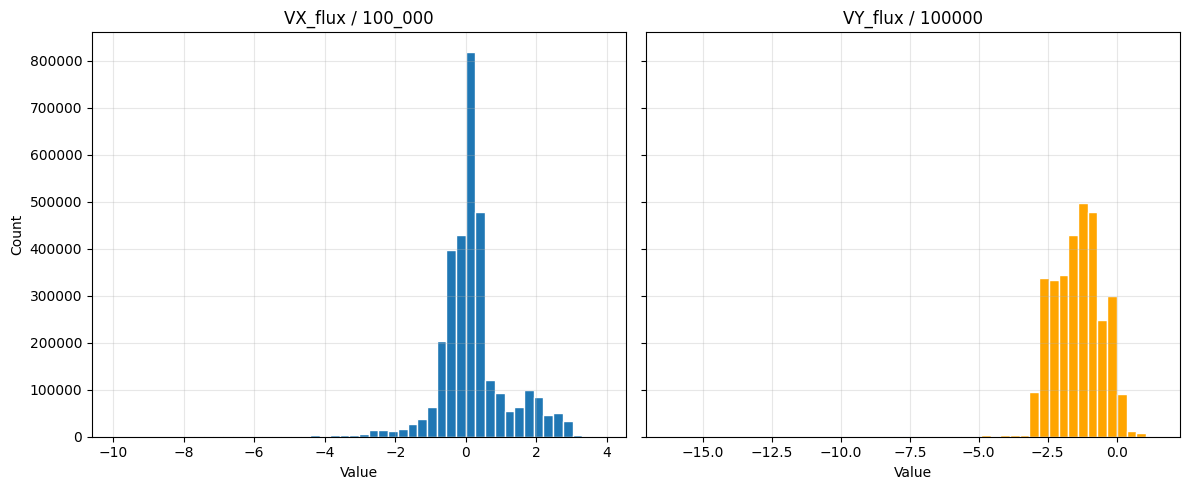

In [15]:
# Extract the last two columns
vx_flux_scaled = flux_tensor[:, 2].numpy()
vy_flux_scaled = flux_tensor[:, 3].numpy()

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharey = True)

axes[0].hist(vx_flux_scaled, bins = 50, edgecolor = "white")
axes[0].set_title("VX_flux / 100_000")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")
axes[0].grid(alpha = 0.3)

axes[1].hist(vy_flux_scaled, bins = 50, edgecolor = "white", color = "orange")
axes[1].set_title("VY_flux / 100000")
axes[1].set_xlabel("Value")
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

# Export tensor with all flux observations

In [18]:
torch.save(flux_tensor, "data/flux_tensor.pt")